In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('encoders_metrics.csv')
df.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.test_ncc', 'metrics.test_vif', 'metrics.test_mse',
       'metrics.val_loss', 'metrics.train_loss', 'metrics.test_scc',
       'metrics.test_psnr', 'metrics.test_ssim', 'params.loss',
       'params.latent_dim', 'params.epochs', 'params.lr', 'params.model',
       'params.batch_size', 'params.input_shape', 'params.dataset',
       'tags.mlflow.runName', 'tags.mlflow.source.git.commit',
       'tags.mlflow.source.name', 'tags.mlflow.source.type',
       'tags.mlflow.user', 'metrics.kl', 'metrics.recon'],
      dtype='object')

In [22]:
df = df[['params.model', 'metrics.test_ncc', 'metrics.test_vif', 'metrics.test_mse',
       'metrics.val_loss', 'metrics.train_loss', 'metrics.test_scc',
       'metrics.test_psnr', 'metrics.test_ssim', 'params.loss',
       'params.dataset', 'start_time', 'params.epochs']]
df = df[df['params.dataset'] == 'CNR'][:3]
df.to_csv('metrics_encoder_filter.csv')

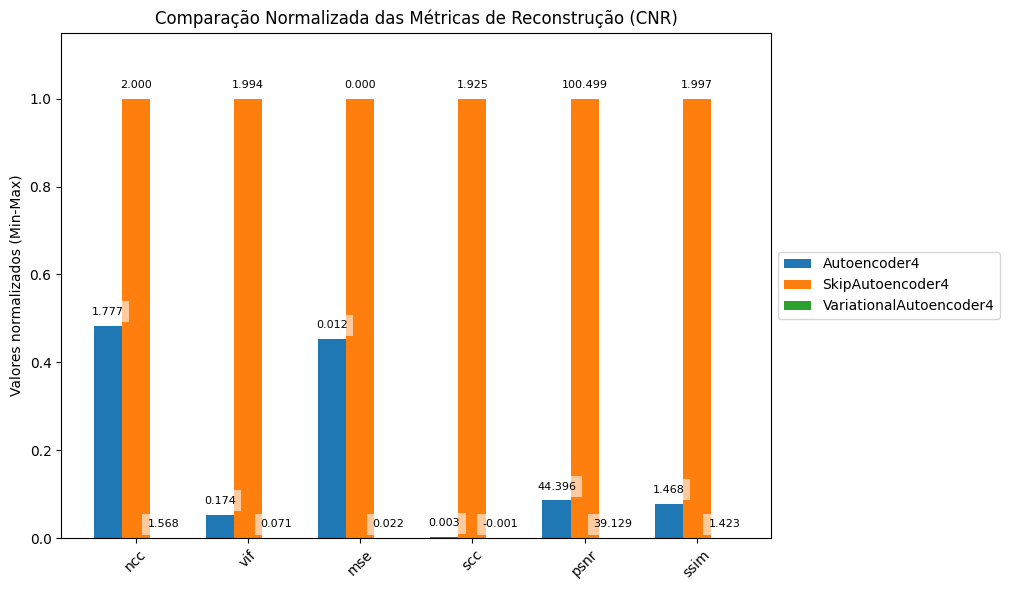

In [21]:
import numpy as np

# ---- FILTRO ----
df_plot = df[
    df['params.dataset'] == 'CNR'
][
    ['params.model',
     'metrics.test_ncc',
     'metrics.test_vif',
     'metrics.test_mse',
     'metrics.test_scc',
     'metrics.test_psnr',
     'metrics.test_ssim']
].copy()

df_plot = df_plot.iloc[:3]

models = df_plot['params.model'].values
metric_cols = df_plot.columns[1:]
values = df_plot[metric_cols].values.astype(float)

# ---- INVERTER MÉTRICAS ONDE MENOR É MELHOR ----
invert_metrics = ['metrics.test_mse']

for idx, metric in enumerate(metric_cols):
    if metric in invert_metrics:
        values[:, idx] = -values[:, idx]

# ---- NORMALIZAÇÃO MIN-MAX POR MÉTRICA ----
min_vals = values.min(axis=0)
max_vals = values.max(axis=0)
denominator = np.where(max_vals - min_vals == 0, 1, max_vals - min_vals)
values_norm = (values - min_vals) / denominator

# ---- PLOT ----
n_metrics = len(metric_cols)
x = np.arange(n_metrics)
width = 0.25

plt.figure(figsize=(12, 6))

for i in range(len(models)):
    bars = plt.bar(x + i * width, values_norm[i], width, label=models[i])
    
    for j, bar in enumerate(bars):
        height = bar.get_height()
        original_value = df_plot.iloc[i][metric_cols[j]]
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{original_value:.3f}",
            ha='center',
            va='bottom',
            fontsize=8,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
        )

plt.xticks(
    x + width * (len(models) - 1) / 2,
    [m.replace('metrics.test_', '') for m in metric_cols],
    rotation=45
)

plt.ylabel('Valores normalizados (Min-Max)')
plt.title('Comparação Normalizada das Métricas de Reconstrução (CNR)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylim(0, 1.15)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [34]:
df_2 = pd.read_csv('/home/lucas.ocunha/ConditionalAutoencoder/metrics_classifiers_0.csv')
df_2.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.val_acc', 'metrics.train_acc', 'metrics.val_loss',
       'metrics.train_loss', 'metrics.test_precision-UFPR05',
       'metrics.test_precision-camera1', 'metrics.test_f1-UFPR04',
       'metrics.test_f1-camera6', 'metrics.test_acc-camera8',
       'metrics.test_acc-camera3', 'metrics.test_precision-camera2',
       'metrics.test_precision-camera5', 'metrics.test_acc-camera5',
       'metrics.test_acc-UFPR04', 'metrics.test_precision-UFPR04',
       'metrics.test_f1-camera5', 'metrics.test_f1-camera7',
       'metrics.test_acc-UFPR05', 'metrics.test_precision-camera9',
       'metrics.test_f1-camera3', 'metrics.test_f1-UFPR05',
       'metrics.test_precision-camera8', 'metrics.test_acc-camera6',
       'metrics.test_acc-camera1', 'metrics.test_acc-camera4',
       'metrics.test_precision-camera4', 'metrics.test_f1-camera2',
       'metrics.test_f1-camera4', 'metrics.test_precision-came

In [46]:
df_filter = df_2[
    [
        'status',
        'params.n_images_to_train',
        'params.model',
        'params.epochs',
        'params.encoder_dataset',
        'params.dataset_classifier',
        'tags.mlflow.source.name',
        'tags.mlflow.runName',

        'metrics.test_acc-PUC',
        'metrics.test_acc-UFPR04',
        'metrics.test_acc-UFPR05',
        'metrics.test_acc-camera1',
        'metrics.test_acc-camera2',
        'metrics.test_acc-camera3',
        'metrics.test_acc-camera4',
        'metrics.test_acc-camera5',
        'metrics.test_acc-camera6',
        'metrics.test_acc-camera7',
        'metrics.test_acc-camera8',
        'metrics.test_acc-camera9'
    ]
]

df_filter = df_filter[df_filter['params.encoder_dataset'] == 'CNR']
df_filter = df_filter[df_filter['status'] == 'FINISHED']
df_filter = df_filter[df_filter['params.dataset_classifier'] == 'PUC']
target_images = [64, 128, 256, 512, 1024]

target_models = [
    'Encoder0_Classifier',
    'VariationalEncoder0_Classifier',
    'SkipEncoder0_Classifier'
]

df_selected = (
    df_filter[
        (df_filter['params.model'].isin(target_models)) &
        (df_filter['params.n_images_to_train'].isin(target_images))
    ]
    # escolha qual execução manter:
    .drop_duplicates(
        subset=['params.model', 'params.n_images_to_train'],
        keep='first'
    )
    .sort_values(['params.model', 'params.n_images_to_train'])
)

df_selected.to_csv('metrics_classifiers0_filter.csv', index=False)
df_selected.columns

Index(['status', 'params.n_images_to_train', 'params.model', 'params.epochs',
       'params.encoder_dataset', 'params.dataset_classifier',
       'tags.mlflow.source.name', 'tags.mlflow.runName',
       'metrics.test_acc-PUC', 'metrics.test_acc-UFPR04',
       'metrics.test_acc-UFPR05', 'metrics.test_acc-camera1',
       'metrics.test_acc-camera2', 'metrics.test_acc-camera3',
       'metrics.test_acc-camera4', 'metrics.test_acc-camera5',
       'metrics.test_acc-camera6', 'metrics.test_acc-camera7',
       'metrics.test_acc-camera8', 'metrics.test_acc-camera9'],
      dtype='object')

In [48]:
df_selected.to_csv('metrics_classifiers0_filter.csv', index=False)

# Análise das fusões

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('fusion_metrics.csv')

In [13]:
df[df['batch'] == 64].sort_values('accuracy')

,tipo_encoder,dataset_encoder,dataset_test,batch,tecnica_fusao,precision,precision_std,accuracy,accuracy_std
26704,VariationalEncoder,CNR,UFPR04,64,mult,0.292098,0.0,0.351083,0.0
26703,VariationalEncoder,CNR,UFPR04,64,max,0.267410,0.0,0.368801,0.0
27063,VariationalEncoder,PKLot,UFPR04,64,max,0.405715,0.0,0.407032,0.0
9425,Encoder,CNR,UFPR04,64,vote,0.399997,0.0,0.407251,0.0
27061,VariationalEncoder,PKLot,UFPR04,64,sum,0.412820,0.0,0.409433,0.0
...,...,...,...,...,...,...,...,...,...
17289,SkipEncoder,CNR,camera2,64,max,0.970521,0.0,0.970522,0.0
17287,SkipEncoder,CNR,camera2,64,sum,0.970521,0.0,0.970522,0.0
17288,SkipEncoder,CNR,camera2,64,mean_probs,0.970521,0.0,0.970522,0.0
17290,SkipEncoder,CNR,camera2,64,mult,0.971662,0.0,0.971655,0.0
